# Online Shopping Behavior – Exploratory Data Analysis
**Dataset:** Online Shopping (588 records , 9 features)  
**Goal:** Clean the data explore patterns and extract actionable insights about customer behavior

## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic parameters for plotting
sns.set_theme(style="whitegrid")
print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 1: Data Understanding

In [3]:
# Load the original dataset
df_original = pd.read_csv('../data/online_shopping.csv')
print('Data has been read from the file')

print('\nDataset size:')
print(f'Number of rows: {df_original.shape[0]}')
print(f'Number of columns: {df_original.shape[1]}')

Data has been read from the file

Dataset size:
Number of rows: 588
Number of columns: 9


In [4]:
df_original.head(10)

,age,gender,time_on_site,pages_viewed,device,purchase_amount,discount_used,click_rate,return_customer
0,63.0,Male,18.685621,3,mobile,289.253886,Yes,35.878814,1.0
1,43.0,Female,4.411306,9,Desktop,224.366091,No,177.625321,0.0
2,35.0,Male,9.217575,17,Mobile,254.559993,Yes,42.648411,0.0
3,NaN,Female,13.183255,4,Desktop,66.949884,No,34.546995,1.0
4,NaN,Female,17.709027,3,mobile,170.062225,Yes,56.095720,0.0
5,59.0,Male,13.923434,15,mobile,292.988001,No,48.740125,0.0
6,45.0,Male,7.349641,7,mobile,167.358900,Yes,47.675041,0.0
7,51.0,Female,13.322453,12,NaN,21.820469,Yes,165.859939,0.0
8,55.0,Male,16.389287,15,Desktop,280.710393,Yes,135.236273,1.0
9,21.0,Female,12.459039,16,mobile,85.398233,No,159.539694,0.0


In [5]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588 entries, 0 to 587
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              544 non-null    float64
 1   gender           560 non-null    object 
 2   time_on_site     540 non-null    float64
 3   pages_viewed     582 non-null    object 
 4   device           545 non-null    object 
 5   purchase_amount  586 non-null    float64
 6   discount_used    583 non-null    object 
 7   click_rate       583 non-null    float64
 8   return_customer  560 non-null    float64
dtypes: float64(5), object(4)
memory usage: 41.5+ KB


In [6]:
print('Missing values analysis:')
missing_count = df_original.isnull().sum()
missing_percent = (df_original.isnull().sum() / len(df_original) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': df_original.columns,
    'Missing Count': missing_count.values,
    'Percentage (%)': missing_percent.values
})

print(missing_df.to_string(index=False))

Missing values analysis:
         Column  Missing Count  Percentage (%)
            age             44            7.48
         gender             28            4.76
   time_on_site             48            8.16
   pages_viewed              6            1.02
         device             43            7.31
purchase_amount              2            0.34
  discount_used              5            0.85
     click_rate              5            0.85
return_customer             28            4.76


In [7]:
print('Dataset summary statistics:')
df_original.describe(include='all').round(2)

Dataset summary statistics:


,age,gender,time_on_site,pages_viewed,device,purchase_amount,discount_used,click_rate,return_customer
count,544.00,560,540.00,582,545,586.00,583,583.00,560.00
unique,NaN,2,NaN,20,3,NaN,2,NaN,NaN
top,NaN,Male,NaN,7,mobile,NaN,No,NaN,NaN
freq,NaN,315,NaN,38,184,NaN,293,NaN,NaN
mean,41.45,NaN,9.78,NaN,NaN,153.13,NaN,100.17,0.54
std,13.20,NaN,5.28,NaN,NaN,86.51,NaN,58.90,0.50
min,18.00,NaN,-4.59,NaN,NaN,10.05,NaN,-57.31,0.00
25%,30.75,NaN,6.06,NaN,NaN,71.87,NaN,58.59,0.00
50%,41.50,NaN,9.51,NaN,NaN,158.24,NaN,101.15,1.00
75%,53.00,NaN,13.16,NaN,NaN,225.78,NaN,141.78,1.00


## Step 2: Data Cleaning and Preprocessing

In this section, we prepare a cleaner version of the dataset so it is ready for analysis.

### 2.1 Handling Missing Values
We first convert invalid entries such as `many` in `pages_viewed` into missing values, then fill numerical columns with the **median** and categorical columns with the **mode**.

In [8]:
# Create a working copy of the original dataset
df_clean = df_original.copy()

# Convert columns that should be numeric
df_clean['pages_viewed'] = pd.to_numeric(df_clean['pages_viewed'], errors='coerce')
df_clean['return_customer'] = pd.to_numeric(df_clean['return_customer'], errors='coerce')

missing_before = int(df_clean.isnull().sum().sum())

# Fill missing numerical values with the median
num_cols = ['age', 'time_on_site', 'pages_viewed', 'purchase_amount', 'click_rate', 'return_customer']
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill missing categorical values with the mode
cat_cols = ['gender', 'device', 'discount_used']
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

missing_after = int(df_clean.isnull().sum().sum())
print(f"Missing values before cleaning: {missing_before}")
print(f"Missing values after cleaning: {missing_after}")

Missing values before cleaning: 239
Missing values after cleaning: 0


### 2.2 Data Type Correction
After filling missing values, we convert the numeric fields to the correct types for analysis.

In [9]:
# Convert float-based numeric columns to integers where needed
df_clean['pages_viewed']    = df_clean['pages_viewed'].round().astype(int)
df_clean['return_customer'] = df_clean['return_customer'].round().astype(int)
print('Data types corrected.')
df_clean.dtypes

Data types corrected.


age                float64
gender              object
time_on_site       float64
pages_viewed         int64
device              object
purchase_amount    float64
discount_used       object
click_rate         float64
return_customer      int64
dtype: object

### 2.3 Categorical Standardization
Fixing naming inconsistencies (e.g., 'mobile' vs 'Mobile') to ensure uniform labels.

In [10]:
# Standardize text formatting in categorical columns
df_clean['device'] = df_clean['device'].str.strip().str.capitalize()
df_clean['gender'] = df_clean['gender'].str.strip().str.capitalize()
df_clean['discount_used'] = df_clean['discount_used'].str.strip().str.capitalize()

print("Device categories after standardization:")
print(df_clean['device'].value_counts())
print("\nGender categories after standardization:")
print(df_clean['gender'].value_counts())

Device categories after standardization:
device
Mobile     409
Desktop    179
Name: count, dtype: int64

Gender categories after standardization:
gender
Male      343
Female    245
Name: count, dtype: int64


### 2.4 Anomaly Detection and Treatment
Fixing logical errors such as negative values in duration or rate columns.

In [11]:
# Count negative values before correcting them
negative_time = int((df_clean['time_on_site'] < 0).sum())
negative_click = int((df_clean['click_rate'] < 0).sum())

# Replace negative values with the median of valid records
valid_time_median = df_clean.loc[df_clean['time_on_site'] >= 0, 'time_on_site'].median()
valid_click_median = df_clean.loc[df_clean['click_rate'] >= 0, 'click_rate'].median()

df_clean.loc[df_clean['time_on_site'] < 0, 'time_on_site'] = valid_time_median
df_clean.loc[df_clean['click_rate'] < 0, 'click_rate'] = valid_click_median

print(f"Negative time_on_site values fixed: {negative_time}")
print(f"Negative click_rate values fixed: {negative_click}")

Negative time_on_site values fixed: 16
Negative click_rate values fixed: 26


### 2.5 Removing Duplicates and Final Validation

In [12]:
initial_rows = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()

validation_summary = pd.DataFrame({
    'Check': [
        'Remaining missing values',
        'Remaining duplicate rows',
        'Negative time_on_site values',
        'Negative click_rate values'
    ],
    'Value': [
        int(df_clean.isnull().sum().sum()),
        int(df_clean.duplicated().sum()),
        int((df_clean['time_on_site'] < 0).sum()),
        int((df_clean['click_rate'] < 0).sum())
    ]
})
print(f"Removed {initial_rows - df_clean.shape[0]} duplicate rows.")
print(f"Final cleaned dataset shape: {df_clean.shape}")
validation_summary

Removed 21 duplicate rows.
Final cleaned dataset shape: (567, 9)


,Check,Value
0,Remaining missing values,0
1,Remaining duplicate rows,0
2,Negative time_on_site values,0
3,Negative click_rate values,0


### Step 2.6: Exporting Cleaned Data

In [13]:
df_clean.to_csv('../data/online_shopping_cleaned.csv', index=False)
print("Cleaned dataset saved as 'online_shopping_cleaned.csv'")
df_clean.head()

Cleaned dataset saved as 'online_shopping_cleaned.csv'


,age,gender,time_on_site,pages_viewed,device,purchase_amount,discount_used,click_rate,return_customer
0,63.0,Male,18.685621,3,Mobile,289.253886,Yes,35.878814,1
1,43.0,Female,4.411306,9,Desktop,224.366091,No,177.625321,0
2,35.0,Male,9.217575,17,Mobile,254.559993,Yes,42.648411,0
3,41.5,Female,13.183255,4,Desktop,66.949884,No,34.546995,1
4,41.5,Female,17.709027,3,Mobile,170.062225,Yes,56.095720,0



## Step 3: Univariate Analysis
We examine each feature individually to understand its distribution central tendency and spread


### 3.1 Summary Statistics for Numerical Features 

In [14]:
num_features = ['age', 'time_on_site', 'pages_viewed', 'purchase_amount', 'click_rate']
df_clean[num_features].describe().round(2)

,age,time_on_site,pages_viewed,purchase_amount,click_rate
count,567.00,567.00,567.00,567.00,567.00
mean,41.47,10.02,9.90,152.93,105.82
std,12.67,4.65,5.17,86.30,51.82
min,18.00,0.15,1.00,10.05,1.59
25%,32.00,7.16,6.00,72.01,69.25
50%,41.50,9.51,10.00,158.24,103.60
75%,52.00,12.59,14.00,224.94,141.13
max,64.00,26.85,19.00,299.31,323.26


### 3.2 Distribution of Purchase Amount

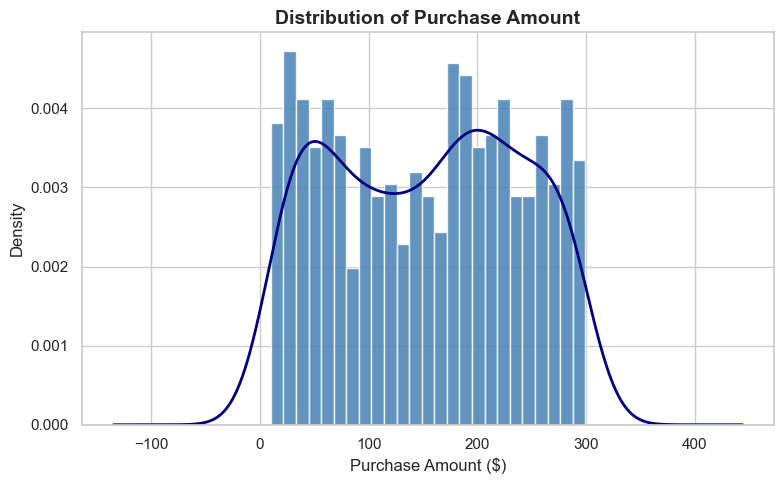

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_clean['purchase_amount'], bins=25, color='steelblue', edgecolor='white', alpha=0.85, density=True)
df_clean['purchase_amount'].plot.kde(ax=ax, color='navy', linewidth=2)
ax.set_title('Distribution of Purchase Amount', fontsize=14, fontweight='bold')
ax.set_xlabel('Purchase Amount ($)'); ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

**Observation:** Purchase amount follows an approximately **uniform distribution** between \$10 and \$300 There are no extreme outliers


### 3.3 Distribution of Customer Age

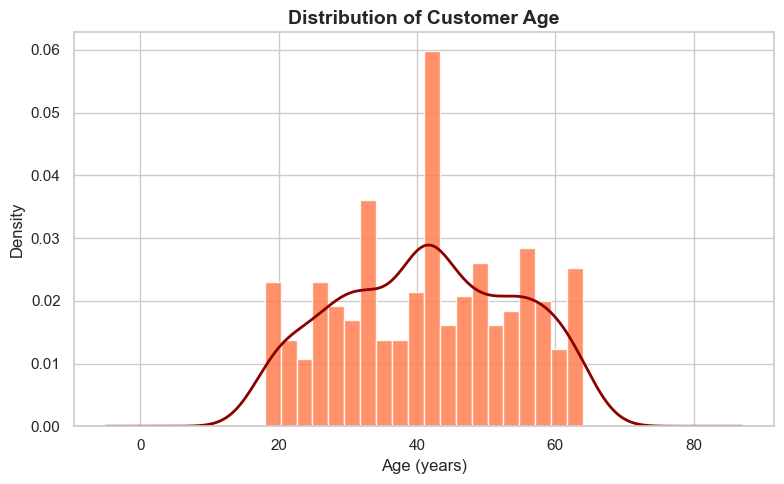

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_clean['age'], bins=20, color='coral', edgecolor='white', alpha=0.85, density=True)
df_clean['age'].plot.kde(ax=ax, color='darkred', linewidth=2)
ax.set_title('Distribution of Customer Age', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)'); ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

**Observation:** Age ranges from 18 to 64 with a mean of an almost 41.5 years The distribution is approximately **uniform** suggesting the platform attracts shoppers across all adult age groups equally


### 3.4 Categorical Feature Distributions

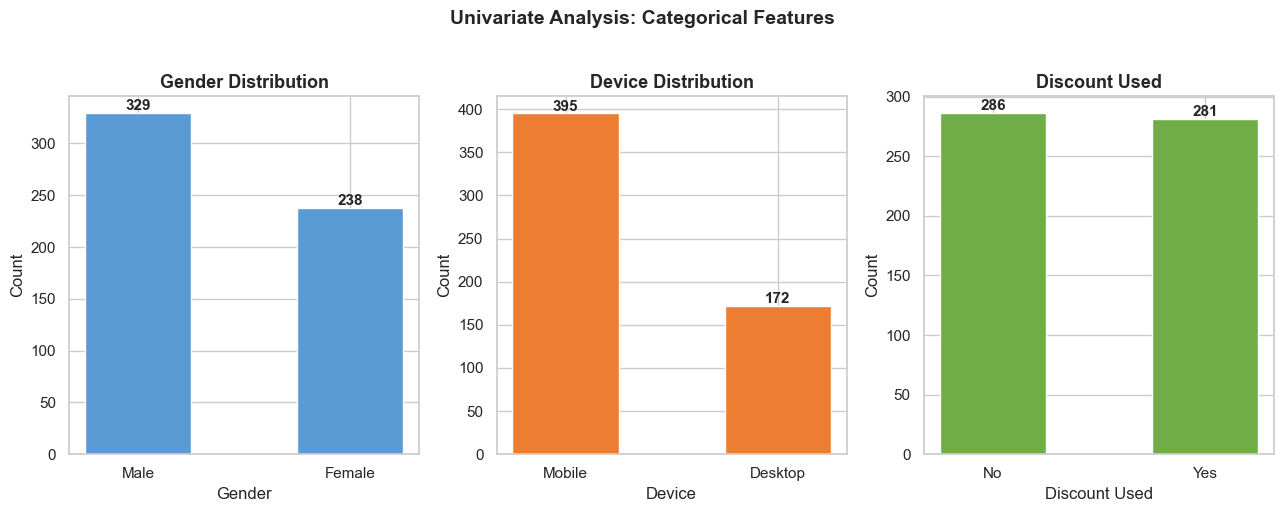

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, (col, title, color) in zip(axes, [
    ('gender', 'Gender Distribution', '#5b9bd5'),
    ('device', 'Device Distribution', '#ed7d31'),
    ('discount_used', 'Discount Used', '#70ad47'),
]):
    counts = df_clean[col].value_counts()
    bars = ax.bar(counts.index, counts.values, color=color, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(col.replace('_',' ').title()); ax.set_ylabel('Count')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3, str(int(bar.get_height())), ha='center', fontsize=11, fontweight='bold')
plt.suptitle('Univariate Analysis: Categorical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- **Gender:** Males slightly outnumber females a 58/42 split
- **Device:** Mobile is the dominant platform (72%) significantly ahead of Desktop (28%)
- **Discount Usage:** Nearly equal split 


### 3.5 Outlier Detection via Boxplots

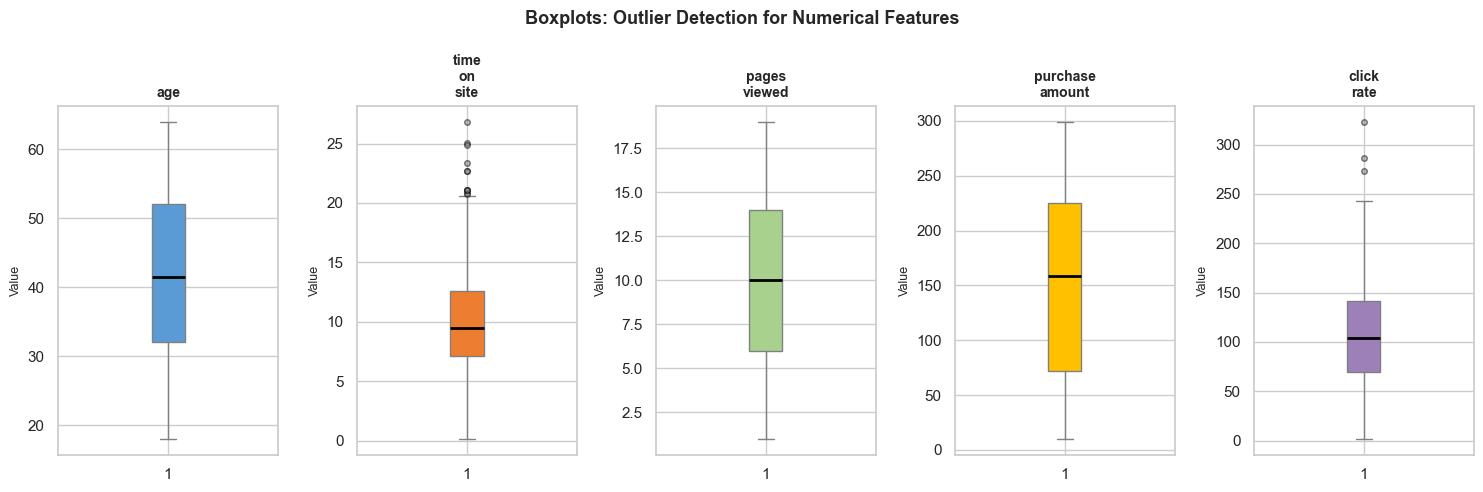

In [18]:
num_plot = ['age', 'time_on_site', 'pages_viewed', 'purchase_amount', 'click_rate']
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
colors = ['#5b9bd5','#ed7d31','#a9d18e','#ffc000','#9e80b8']
for ax, col, color in zip(axes, num_plot, colors):
    ax.boxplot(df_clean[col], patch_artist=True,
               boxprops=dict(facecolor=color, color='gray'),
               medianprops=dict(color='black', linewidth=2),
               whiskerprops=dict(color='gray'), capprops=dict(color='gray'),
               flierprops=dict(marker='o', markersize=4, markerfacecolor='gray', alpha=0.5))
    ax.set_title(col.replace('_','\n'), fontsize=10, fontweight='bold')
    ax.set_ylabel('Value', fontsize=9)
fig.suptitle('Boxplots: Outlier Detection for Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- **Age** and **pages_viewed** have clean, symmetric distributions with no outliers
- **time_on_site** shows upper outliers (sessions lasting up to 27 minutes) likely power users.
- **click_rate** has extreme outliers (up to 323 clicks) but these appear to be valid high-engagement users
- **purchase_amount** shows no outliers values are bounded naturally between \$10 and \$300.